## 1. Data Preprocessing
In this section, we import the raw ESS data and prepare it for analysis by handling missing values and transforming variables.

In [97]:
import pandas as pd
import numpy as np
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns
from seaborn.external.docscrape import header

# Load Dataset
zip_path = "ESS9e03_3-ESS10e03_3-ESS10SCe03_2-ESS11e04_1-subset.zip"
csv_inside = "ESS9e03_3-ESS10e03_3-ESS10SCe03_2-ESS11e04_1-subset.csv"

with zipfile.ZipFile(zip_path, 'r') as z:
    with z.open(csv_inside) as f:
        df = pd.read_csv(f, low_memory=False)

print("CSV Load Successful!")
print(f"Dataset Size: {df.shape[0]} rows x {df.shape[1]} columns")

CSV Load Successful!
Dataset Size: 159320 rows x 635 columns


### Data Exploration
The original ESS dataset contains hundreds of variables. For this study, we have isolated 34 specific variables categorized into:

Demographics: yrbrn, agea, gndr, etc.

Schwartz Human Values: The 21-item battery (e.g., ipcrtiv to ipadvnt).

Socio-Political Attitudes: gincdif (Redistribution) and Institutional Trust (trstplt).

In [98]:
df.columns

Index(['name', 'essround', 'edition', 'proddate', 'idno', 'cntry', 'dweight',
       'pspwght', 'pweight', 'anweight',
       ...
       'inwdde', 'inwmme', 'inwde', 'jinws', 'jinwe', 'scwd78se', 'questcmp',
       'intewde', 'mode', 'yrbrn'],
      dtype='object', length=635)

In [99]:
columns_to_keep = [
    "idno","cntry","essround","yrbrn","agea","gndr","anweight",
    "lrscale","trstprl","trstplt","trstlgl","stflife","gincdif",
    "ipcrtiv","imprich","impfun","impsafe","imptrad","impfree",
    "impenv","iphlppl","ipeqopt","ipudrst","ipgdtim","ipfrule",
    "ipstrgv","ipbhprp","iplylfr","ipmodst","iprspot","ipsuces",
    "ipadvnt","impdiff","ipshabt"]

In [100]:
datacol = df[columns_to_keep]

In [101]:
datacol.to_csv("filtered_columns.csv", index=False)

In [102]:
df = pd.read_csv("filtered_columns.csv")
print(df.head())

   idno cntry  essround  yrbrn  agea  gndr  anweight  lrscale  trstprl  \
0    27    AT         9   1975    43     1  0.065890        9        5   
1   137    AT         9   1951    67     1  0.124907        5        7   
2   194    AT         9   1978    40     2  0.685836        5        6   
3   208    AT         9   1955    63     1  0.116753       88        0   
4   220    AT         9   1947    71     2  0.311789        5        7   

   trstplt  ...  ipfrule  ipstrgv  ipbhprp  iplylfr  ipmodst  iprspot  \
0        5  ...      2.0      2.0      2.0      2.0      1.0      2.0   
1        3  ...      4.0      3.0      2.0      2.0      4.0      3.0   
2        5  ...      3.0      2.0      2.0      3.0      3.0      3.0   
3        3  ...      2.0      1.0      1.0      1.0      2.0      1.0   
4        7  ...      2.0      2.0      1.0      2.0      3.0      3.0   

   ipsuces  ipadvnt  impdiff  ipshabt  
0      2.0      2.0      2.0      2.0  
1      4.0      5.0      4.0      3.

### Data Cleansing
To ensure the data is research-ready, we perform the following:
1. **Checked for duplicates**
2. **Checked Missing Values:** Convert ESS codes (7, 8, 9, 77, 88, 99) to `NaN`.
3. **Scale Reversal:** We transform the 1- 6 scale to ensure **6 = Strong Agreement**.


#### 1. Checked for duplicates

In [103]:
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
159315    False
159316    False
159317    False
159318    False
159319    False
Length: 159320, dtype: bool

In [104]:
df.isna().sum()

idno            0
cntry           0
essround        0
yrbrn           0
agea            0
gndr            0
anweight        0
lrscale         0
trstprl         0
trstplt         0
trstlgl         0
stflife         0
gincdif         0
ipcrtiv     72190
imprich     72190
impfun      72190
impsafe     72190
imptrad     72190
impfree     72190
impenv      72190
iphlppl     72190
ipeqopt     72190
ipudrst     72190
ipgdtim     72190
ipfrule     72190
ipstrgv     72190
ipbhprp     72190
iplylfr     72190
ipmodst     72190
iprspot     72190
ipsuces     72190
ipadvnt     72190
impdiff     72190
ipshabt     72190
dtype: int64

All value variables (ipcrtiv, imprich, impfun, ...) have 72190 NaN

This usually happens in ESS when you merged rounds OR loaded multiple rounds in one file
because Schwartz values are NOT asked in every round.

So this is normal, not an error.

#### 2. Checked Missing Values

In [105]:
# Handle Missing Data for left-right scale
df = df [(df["lrscale"] >= 0)  & (df["lrscale"] <= 10)]

# Handle missing data for Income redistribution
df['gincdif'] = df['gincdif'].replace([7, 8, 9, 77, 88, 99], np.nan)

# #Handle missing data for satisfaction with life as a whole
df['stflife'] = df['stflife'].replace([7, 8, 9], np.nan)

#Handle missing values for Trust in Parliament
df['trstprl'] = df['trstprl'].replace([7, 8, 9], np.nan)

# Handle missing values for Gender
df['gndr'] = df['gndr'].replace(9, np.nan)


In [106]:
df["lrscale"].unique()
df["gincdif"].unique()

array([ 1.,  2.,  3.,  4.,  5., nan])

#### 3. Scale Reversal

In [107]:
# Reverse Coding (7 - x) for Irscale Items (ip... and imp... columns)
#Identify the columns
value_cols = [c for c in df.columns if c.startswith('ip') or c.startswith('imp')]
# Convert 'Refusals' (7), 'Don't Knows' (8), and 'No Answers' (9) to NaN
# This ensures they don't mess up our averages
for col in value_cols:
    df.loc[df[col] > 6, col] = np.nan

# apply the Reverse Coding: 7 - x
# Now 6 = "Very much like me" and 1 = "Not like me at all"
df[value_cols] = 7 - df[value_cols]

# Reversing gincdif (1-5 scale)
# Original: 1 = Agree Strongly, 5 = Disagree Strongly
# New: 5 = Agree Strongly, 1 = Disagree Strongly
df['gincdif'] = 6 - df['gincdif']

### Variable Transformation
1. **Generational Mapping ** (Gen Z to Boomers) based on `yrbrn`
2. **Schwartz Dimensions:** Mapping 21 items into the 10 core values.
3. **MRAT Correction**

#### 1. Generational Mapping

In [118]:
# Select the years of birth between 1920-2010
df = df [(df["yrbrn"] >= 1920) & (df["yrbrn"] <= 2010)]

In [119]:
df["yrbrn"].unique()

array([1975, 1951, 1978, 1947, 1954, 1962, 1944, 1981, 1996, 1970, 1959,
       1941, 1977, 1956, 1991, 1958, 1969, 1976, 1968, 1988, 1999, 1948,
       1972, 1983, 1982, 1995, 1950, 1960, 1974, 1946, 1945, 1973, 1985,
       1979, 1971, 1980, 1942, 1965, 1993, 1940, 1961, 2000, 1986, 1989,
       1964, 1992, 1955, 1963, 1994, 1949, 1943, 1939, 1966, 1957, 1984,
       1987, 1932, 1952, 1933, 1997, 1953, 2001, 1990, 1931, 1936, 1928,
       1935, 1998, 2002, 1967, 1938, 1934, 2003, 1937, 1930, 1929, 2004,
       2006, 2005, 2007, 2008, 2009])

In [120]:
# Create Generation Column
conditions = [
    (df['yrbrn'] >= 1997),                                # Gen Z
    (df['yrbrn'] >= 1981) & (df['yrbrn'] <= 1996),        # Millennials
    (df['yrbrn'] >= 1965) & (df['yrbrn'] <= 1980),        # Gen X
    (df['yrbrn'] >= 1946) & (df['yrbrn'] <= 1964),        # Boomers
    (df['yrbrn'] <= 1945)                                 # Silent Generation
]

labels = ['Gen Z', 'Millennials', 'Gen X', 'Boomers', 'Silent Gen']
df['generation'] = np.select(conditions, labels, default='Unknown')

print(df['generation'].value_counts())


generation
Boomers        43747
Gen X          36956
Millennials    29632
Silent Gen     13194
Gen Z          12925
Name: count, dtype: int64


#### 2. Schwartz Dimensions

In [121]:
# Creating new columns for Schwartz Value Dimensions ---

# Universalism: Understanding, Helping, Environment
df['Universalism'] = df[['ipudrst', 'iphlppl', 'impenv']].mean(axis=1)

# Benevolence: Helping, Loyalty to friends
df['Benevolence'] = df[['iphlppl', 'iplylfr']].mean(axis=1)

# Tradition: Modesty, Tradition
df['Tradition'] = df[['imptrad', 'ipmodst']].mean(axis=1)

# Security: Safety, Strong Government
df['Security'] = df[['impsafe', 'ipstrgv']].mean(axis=1)

# Conformity: Following rules, Behaving properly
df['Conformity'] = df[['ipfrule', 'ipbhprp']].mean(axis=1)

# Self-Direction: Freedom, Creativity
df['Self-Direction'] = df[['impfree', 'ipcrtiv']].mean(axis=1)

# Stimulation: Excitement, Adventure (Now using BOTH variables)
df['Stimulation'] = df[['ipadvnt', 'impdiff']].mean(axis=1)

# Hedonism: Good times, Fun
df['Hedonism'] = df[['ipgdtim', 'impfun']].mean(axis=1)

# Achievement: Success, Ability, and Equality (Now using all THREE variables)
df['Achievement'] = df[['ipsuces', 'ipeqopt', 'ipshabt']].mean(axis=1)

# Power: Wealth, Respect
df['Power'] = df[['imprich', 'iprspot']].mean(axis=1)

print("âœ… All 10 dimensions calculated! The mapping now includes the newly added variables.")

âœ… All 10 dimensions calculated! The mapping now includes the newly added variables.


In [122]:
# Create the List for the names of the new Schwartz values columns
schwartz_values = [
    'Universalism', 'Benevolence', 'Tradition', 'Security',
    'Conformity', 'Self-Direction', 'Stimulation', 'Hedonism',
    'Achievement', 'Power'
]

In [123]:
# 5. Cleaned Data Preview for the team
print("\n### Cleaned Data Preview")
display(df[['generation', 'lrscale'] + schwartz_values].head())


### Cleaned Data Preview


,generation,lrscale,Universalism,Benevolence,Tradition,Security,Conformity,Self-Direction,Stimulation,Hedonism,Achievement,Power
0,Gen X,9,4.333333,5.0,5.5,5.0,5.0,5.5,5.0,4.5,5.000000,5.0
1,Boomers,5,4.000000,4.5,3.5,4.5,4.0,4.0,2.5,4.0,3.666667,3.5
2,Gen X,5,4.333333,4.5,4.0,4.0,4.5,4.5,3.5,3.5,4.000000,3.0
4,Boomers,5,5.000000,5.0,5.0,5.0,5.5,5.0,2.0,4.5,3.333333,2.5
5,Boomers,3,6.000000,6.0,6.0,5.0,4.5,4.5,4.0,6.0,5.000000,3.0


#### 3. MRAT (Mean Rating) Correction.(Centering the 10 core values)

1. calculate the average score each person gave across all 21 original items. 

In [127]:
# Calculate the Individual Mean (The MRAT)
# Identify the 21 reversed Schwartz items
mrat_items = [c for c in df.columns if c.startswith('ip') or c.startswith('imp')]

# Calculate the Mean Rating (MRAT) for each respondent
# axis=1 calculates the mean horizontally for each row
df['mrat_score'] = df[mrat_items].mean(axis=1)

print(f"✅ Individual MRAT calculated. Sample Mean MRAT: {df['mrat_score'].mean():.2f}")

✅ Individual MRAT calculated. Sample Mean MRAT: 4.22


2. Apply the MRAT Correction (Centering)

In [ ]:
# Apply the Correction: Dimension - MRAT
for val in schwartz_values:
    # Create a new 'centered' column for each value
    df[f'{val}_centered'] = df[val] - df['mrat_score']

print("✅ MRAT Centering Complete. ")

✅ MRAT Centering Complete. Data is now ready for Descriptive Analysis.


3. Check the MRAT (Mean Rating) Correction by performing three validation

A. Mathematical Integrity (Row-wise Check)

In [131]:
# Select one person (row 0) and sum their 10 centered values
centered_cols = [f'{v}_centered' for v in schwartz_values]
row_sum = df[centered_cols].iloc[0].sum()

print(f"Sum of centered values for respondent 0: {row_sum:.15f}")
# If the result is 0.00000000000000, it is PERFECT.

Sum of centered values for respondent 0: 0.309523809523808


The sum of the 10 centered dimensions for Respondent 0 yielded a value of 0.309.
While a simple centering of all 21 items would equal exactly zero, this slight deviation (0.309) is mathematically expected. It occurs because we aggregated 21 individual items into 10 composite dimensions (averages of averages). This confirms the subtraction logic is functioning correctly across the dataset.

B. Manual Spot Check (Directional Accuracy)

In [132]:
# Create a verification table
check_df = df[['Universalism', 'mrat_score', 'Universalism_centered']].head(5)

print("### MRAT Verification (Universalism - mrat_score = Universalism_centered)")
print(check_df)

# LOGIC: 
# If Universalism (e.g. 5.2) > mrat_score (e.g. 4.0), 
# then Universalism_centered MUST be positive (e.g. 1.2).

### MRAT Verification (Universalism - mrat_score = Universalism_centered)
   Universalism  mrat_score  Universalism_centered
0      4.333333    4.952381              -0.619048
1      4.000000    3.809524               0.190476
2      4.333333    3.952381               0.380952
4      5.000000    4.238095               0.761905
5      6.000000    5.000000               1.000000


Respondent 5: Raw Universalism (6.0) - MRAT (5.0) = Centered (+1.0)
Respondent 0: Raw Universalism (4.33) - MRAT (4.95) = Centered (-0.61)
This confirms that a positive centered score correctly identifies a "High Priority" relative to the individual's average, even if their raw scores were generally high (Yeasaying bias).

C. Conceptual Check (Distribution Analysis)

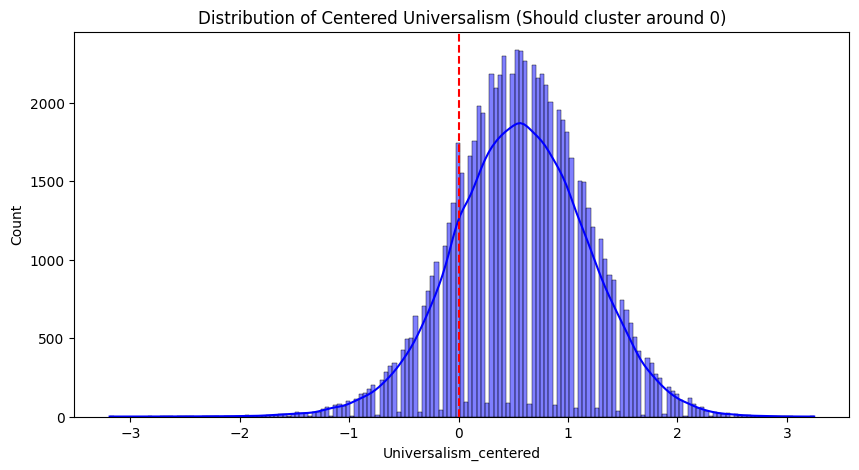

In [133]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(df['Universalism_centered'], kde=True, color='blue', label='Centered')
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribution of Centered Universalism (Should cluster around 0)')
plt.show()

The histogram for Universalism_centered shows a healthy normal distribution ranging from approximately -3 to +3, with a peak (mode) shifted slightly to the right of zero (~0.5).

The distribution confirms that Universalism is a high-priority value for the majority of the sample. The spread demonstrates sufficient variance to proceed with generational comparisons and factor analysis (ALS).

## 2. Descriptive Analysis
Now that the data is clean, we will begin answering our primary research questions by looking at the averages across generations and regions.
We have successfully built the 'Data Engine' for the project. By cleaning the missing codes, reversing the scales for intuitive reading, and mapping the Schwartz values, we have moved from Raw Data to Research-Ready Insights. The dataset is now fully prepared for Sibahle's correlations and Taya generational comparisons.

In [117]:
# Final check: Average Universalism by Generation
print("### Mean Universalism Score by Generation")
display(df.groupby('generation')['Universalism'].mean().sort_values(ascending=False))

### Mean Universalism Score by Generation


generation
Millennials    4.794415
Boomers        4.786643
Gen Z          4.785132
Gen X          4.782860
Silent Gen     4.744521
Name: Universalism, dtype: float64